In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras

import jax
from jax import jit, vmap, grad, value_and_grad, jacobian, random
from jax import numpy as jnp

import mujoco

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
xml_path = "model.xml"
m = mujoco.MjModel.from_xml_path(xml_path)
d = mujoco.MjData(m)
dt = m.opt.timestep

In [ ]:
mujoco.mj_resetData(m, d)

kp = 4.0
kv = 2.0
rand_num = 3600
rand_pos = np.random.uniform(low = -1.5*np.pi, high = +1.5*np.pi, size = (rand_num,))

X = []
A = []
U = []

def controller(m, d):
    t = d.time
    des_pos = int(np.floor(t))%rand_num
    x = jnp.hstack([d.qpos, d.qvel])
    u = np.array([kp*(rand_pos[des_pos] - x[0]) + kv*(0.0 - x[2]), 0.0])
    d.ctrl = u
    
    X.append(x)
    A.append(np.array(d.qacc))
    U.append(u)

mujoco.set_mjcb_control(controller)


while(d.time < rand_num):
  mujoco.mj_step(m, d)

X = np.asarray(X)
A = np.asarray(A)
U = np.asarray(U)

np.savez("XAU_data.npz", x = X, a = A, u = U)

In [ ]:
npz_path = "XAU_data.npz"
XAU_data = np.load(npz_path)

X = XAU_data["x"]
A = XAU_data["a"]
U = XAU_data["u"]

In [4]:
N = X.shape[0]
seq_len = 32
n_sequences = N//seq_len

X_sequences = []
U_sequences = []

for i in range(n_sequences):
    start_idx = i*seq_len
    stop_idx = start_idx + seq_len
    X_sequences.append(X[start_idx:stop_idx])
    U_sequences.append(U[start_idx:stop_idx])

X_sequences = jnp.asarray(X_sequences) # shape = (n_sequences, seq_len, x_dim)
U_sequences = jnp.asarray(U_sequences) # shape = (n_sequences, seq_len, u_dim)

key = random.key(0)
key, subkey = random.split(key, num = 2)

X_sequences = random.permutation(subkey, X_sequences, axis = 0)
U_sequences = random.permutation(subkey, U_sequences, axis = 0)

batch_size = 256
steps = n_sequences//batch_size

q_dim = 2
x_dim = 2*q_dim
u_dim = q_dim

rows, cols = jnp.tril_indices(q_dim)
diag_idx = jnp.arange(start = 0, stop = q_dim)

In [5]:
# --------------------------------------------------------------------------- Neural network to approximate M(q)
f_dim = (q_dim*(q_dim + 1))//2

inp_layer = keras.layers.Input(shape = (q_dim,))
layer_1 = keras.layers.Dense(units = 10, activation = "mish")
layer_2 = keras.layers.Dense(units = 10, activation = "mish")
layer_3 = keras.layers.Dense(units = 10, activation = "mish")
out_layer = keras.layers.Dense(units = f_dim, activation = "linear")
f = keras.Sequential([inp_layer, layer_1, layer_2, layer_3, out_layer])


# --------------------------------------------------------------------------- Neural network to approximate V(q)
inp_layer = keras.layers.Input(shape = (q_dim,))
layer_1 = keras.layers.Dense(units = 8, activation = "mish")
layer_2 = keras.layers.Dense(units = 8, activation = "mish")
layer_3 = keras.layers.Dense(units = 8, activation = "mish")
out_layer = keras.layers.Dense(units = 1, activation = "linear", use_bias = False)
g = keras.Sequential([inp_layer, layer_1, layer_2, layer_3, out_layer])


# --------------------------------------------------------------------------- Neural network to approximate D(q)
inp_layer = keras.layers.Input(shape = (q_dim,))
layer_1 = keras.layers.Dense(units = 10, activation = "mish")
layer_2 = keras.layers.Dense(units = 10, activation = "mish")
layer_3 = keras.layers.Dense(units = 10, activation = "mish")
out_layer = keras.layers.Dense(units = f_dim, activation = "linear")
h = keras.Sequential([inp_layer, layer_1, layer_2, layer_3, out_layer])


# ---------------------------------------------------------------------------
t_vars_f = f.trainable_variables
t_vars_g = g.trainable_variables
t_vars_h = h.trainable_variables
t_vars = t_vars_f + t_vars_g + t_vars_h

n_vars_f = len(t_vars_f)
n_vars_g = len(t_vars_g)
n_vars_h = len(t_vars_h)

optimizer = keras.optimizers.Adam(learning_rate = 1e-3)
optimizer.build(t_vars)
opt_vars = optimizer.variables

In [6]:
# -------------------------------------------------------------- M(q)
@jit
def M(t_vars_f, q):
    f_val, _ = f.stateless_call(t_vars_f, [], q[None, ...], training = True)
    L = jnp.zeros(shape = (q_dim, q_dim))
    L = (L.at[rows, cols]).set(f_val[0])
    L = (L.at[diag_idx, diag_idx]).set(jax.nn.softplus(L[diag_idx, diag_idx]))
    return L@jnp.transpose(L)

@jit
def M_inv(t_vars_f, q):
    return jnp.linalg.inv(M(t_vars_f, q))

M_inv_batch = jit(vmap(M_inv, in_axes = [None, 0]))

In [7]:
# -------------------------------------------------------------- V(q)
@jit
def V(t_vars_g, q):
    g_val, _ = g.stateless_call(t_vars_g, [], q[None, ...], training = True)
    return g_val[0, 0]

dV_dq = jit(grad(V, argnums = 1))
dV_dq_batch = jit(vmap(dV_dq, in_axes = [None, 0]))

In [8]:
# -------------------------------------------------------------- D(q)
@jit
def D(t_vars_h, q):
    h_val, _ = h.stateless_call(t_vars_h, [], q[None, ...], training = True)
    L = jnp.zeros(shape = (q_dim, q_dim))
    L = (L.at[rows, cols]).set(h_val[0])
    L = (L.at[diag_idx, diag_idx]).set(jnp.square(L[diag_idx, diag_idx]))
    return L@jnp.transpose(L)

D_batch = jit(vmap(D, in_axes = [None, 0]))

In [9]:
# --------------------------------------------------------------
@jit
def H(t_vars_f, q, q_dot):
    return M(t_vars_f, q)@q_dot

dH_dq = jit(jacobian(H, argnums = 1))
dH_dq_batch = jit(vmap(dH_dq, in_axes = [None, 0, 0]))

In [10]:
@jit
def ODE_Solve(t_vars, X_seq_batch, U_seq_batch):
    t_vars_f = t_vars[:n_vars_f]
    t_vars_g = t_vars[n_vars_f:-n_vars_h]
    t_vars_h = t_vars[-n_vars_h:]

    q_batch = X_seq_batch[:, 0, :q_dim]
    q_dot_batch = X_seq_batch[:, 0, q_dim:]

    for i in range(seq_len):
        u_batch = U_seq_batch[:, i, :]

        q_dot_col_batch = q_dot_batch[..., None]
        u_col_batch = u_batch[..., None]

        M_inv_ = M_inv_batch(t_vars_f, q_batch)
        dH_dq_ = dH_dq_batch(t_vars_f, q_batch, q_dot_batch)
        dV_dq_ = dV_dq_batch(t_vars_g, q_batch)[..., None]
        D_ = D_batch(t_vars_h, q_batch)

        q_ddot_col_batch = M_inv_@((-dH_dq_ + 0.5*jnp.transpose(dH_dq_, axes = [0, 2, 1]) - D_)@q_dot_col_batch - dV_dq_ + u_col_batch)

        q_dot_batch = q_dot_batch + dt*q_ddot_col_batch[..., 0]
        q_batch = q_batch + dt*q_dot_batch

    return q_batch, q_dot_batch

In [11]:
alpha = 5.0

@jit
def loss(t_vars, X_seq_batch, U_seq_batch):
    q_batch = X_seq_batch[:, -1, :q_dim]
    q_dot_batch = X_seq_batch[:, -1, q_dim:]
    q_batch_pred, q_dot_batch_pred = ODE_Solve(t_vars, X_seq_batch, U_seq_batch)
    L =  jnp.mean(jnp.square(q_batch - q_batch_pred) + alpha*jnp.square(q_dot_batch - q_dot_batch_pred))
    return L

_ = loss(t_vars, X_sequences[:batch_size], U_sequences[:batch_size])
valgrad = jit(value_and_grad(loss, argnums = 0, has_aux = False))
_ = valgrad(t_vars, X_sequences[:batch_size], U_sequences[:batch_size])

In [12]:
@jit
def train_step(t_vars, opt_vars, X_seq_batch, U_seq_batch):
    L, grads = valgrad(t_vars, X_seq_batch, U_seq_batch)
    t_vars, opt_vars = optimizer.stateless_apply(opt_vars, grads, t_vars)
    return L, t_vars, opt_vars

In [13]:
loss_values = []

epochs = 150

for epoch in range(1, epochs):

    epoch_loss = 0.0

    for step in range(steps):

        start_idx = step*batch_size
        stop_idx = start_idx + batch_size

        X_seq_batch = X_sequences[start_idx:stop_idx]
        U_seq_batch = U_sequences[start_idx:stop_idx]

        L, t_vars, opt_vars = train_step(t_vars, opt_vars, X_seq_batch, U_seq_batch)

        epoch_loss = epoch_loss + L

    loss_values.append(epoch_loss)

    if(epoch%5 == 0):
        print("Epoch ", epoch, " | loss = ", epoch_loss)

Epoch  5  | loss =  555.9339
Epoch  10  | loss =  408.30942
Epoch  15  | loss =  318.2773
Epoch  20  | loss =  165.09694
Epoch  25  | loss =  82.002174
Epoch  30  | loss =  41.52521
Epoch  35  | loss =  24.474699
Epoch  40  | loss =  16.550497
Epoch  45  | loss =  13.180124
Epoch  50  | loss =  11.233335
Epoch  55  | loss =  9.921042
Epoch  60  | loss =  8.9940405
Epoch  65  | loss =  8.313407
Epoch  70  | loss =  7.7680087
Epoch  75  | loss =  7.3096447
Epoch  80  | loss =  6.983877
Epoch  85  | loss =  6.5379596
Epoch  90  | loss =  6.385745
Epoch  95  | loss =  6.088295
Epoch  100  | loss =  5.880521
Epoch  105  | loss =  5.693003
Epoch  110  | loss =  5.535149
Epoch  115  | loss =  5.4089355
Epoch  120  | loss =  5.311101
Epoch  125  | loss =  5.2262907
Epoch  130  | loss =  5.135269
Epoch  135  | loss =  5.0528727
Epoch  140  | loss =  4.9808106
Epoch  145  | loss =  4.9170446


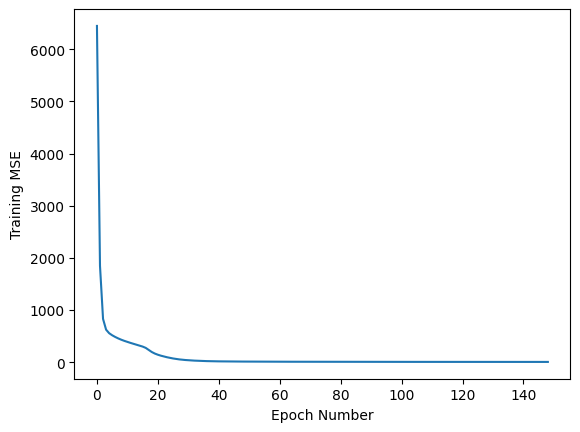

In [14]:
plt.figure()
plt.plot(loss_values)
plt.xlabel("Epoch Number")
plt.ylabel("Training MSE")
plt.show()

In [15]:
t_vars_f = t_vars[:n_vars_f]
t_vars_g = t_vars[n_vars_f:-n_vars_h]
t_vars_h = t_vars[-n_vars_h:]

Q = X[:, :q_dim]
Q_dot = X[:, q_dim:]

Q_dot_col = Q_dot[..., None]
U_col = U[..., None]

M_inv_ = M_inv_batch(t_vars_f, Q)
dH_dq_ = dH_dq_batch(t_vars_f, Q, Q_dot)
dV_dq_ = dV_dq_batch(t_vars_g, Q)[..., None]
D_ = D_batch(t_vars_h, Q)

Q_ddot_col = M_inv_@((-dH_dq_ + 0.5*jnp.transpose(dH_dq_, axes = [0, 2, 1]) - D_)@Q_dot_col - dV_dq_ + U_col)
A_hat = Q_ddot_col[..., 0]

print("RMSE = ", jnp.sqrt(jnp.mean(jnp.square(A - A_hat))))

RMSE =  8.654096


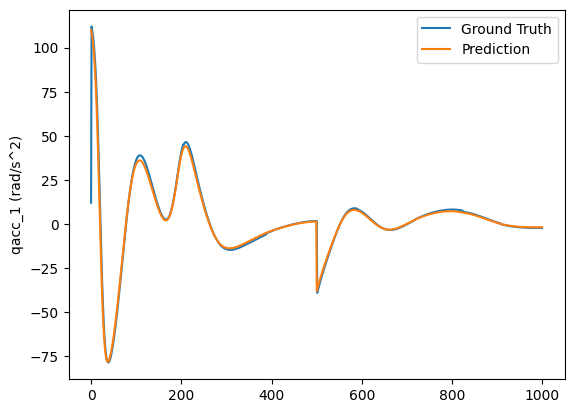

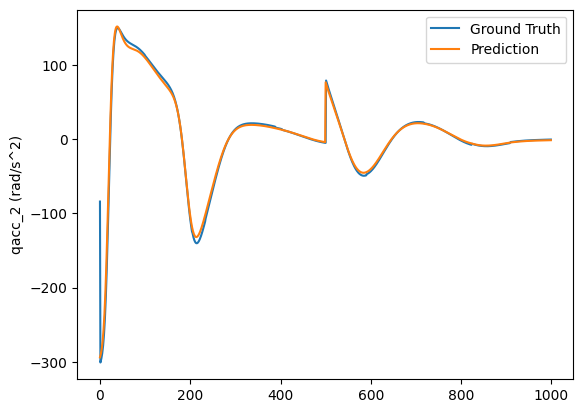

In [25]:
start_idx = 8000
final_idx = 9000

for i in range(q_dim):
    plt.figure()
    plt.plot(A[start_idx:final_idx, i], label = "Ground Truth")
    plt.plot(A_hat[start_idx:final_idx, i], label = "Prediction")
    plt.legend()
    plt.ylabel("qacc_" + str(i+1) + " (rad/s^2)")
    plt.show()